# **Project Name - Flipkart Customer Support Data Analysis**

**Project Type** - EDA

**Contribution** - Indvidual

# **Project Summary**
This project analyzes the Flipkart Customer Support dataset containing 85,907 customer interaction logs. The dataset includes rich information such as interaction channels, issue categories, agent details, response times, and text remarks, alongside our primary target variable: the Customer Satisfaction (CSAT) Score (1-5).

In the high-volume e-commerce sector, achieving excellent customer satisfaction is paramount for retention and brand loyalty. The business context of this analysis is to decode the operational and interaction-level drivers that lead to high or low CSAT scores. Through comprehensive Exploratory Data Analysis (EDA), we aim to reveal hidden patterns—such as whether certain communication channels inherently yield better satisfaction, how the speed of response affects the customer's rating, and if agent tenure or shift timings play a significant role in service quality.

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  **GitHub Link** -Flipkart_EDA.ipynb

# **Problem Statement**
Flipkart focuses on delivering a superior customer experience, but maintaining high satisfaction across millions of transactions is challenging. The support team handles a high volume of diverse queries, and currently, there is a lack of deep understanding regarding what specific variables (like channel, shift, tenure, or response time) most significantly impact CSAT scores. The problem is to identify the root causes of customer dissatisfaction and recognize the patterns of successful interactions to standardize high-quality support across all categories and agents.

**Define Your Business Objective?**

The primary business objective is to identify the key drivers of customer satisfaction by analyzing support ticket data. By correlating variables such as issue category, agent performance metrics, response times, and customer remarks with CSAT scores, Flipkart aims to provide actionable insights. These insights will be used to improve agent training, optimize operational workflows, reduce response times, and ultimately increase the overall CSAT score, leading to higher customer loyalty and reduced churn.

# **General Guildlines :**

1. Well-structured, formatted, and commented code is required.

2. Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

3. The additional credits will have advantages over other students during Star Student selection.

    [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
              without a single error logged. ]
4. Each and every logic should have proper comments.

5. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.

### Chart visualization code
        
1. Why did you pick the specific chart?
2. What is/are the insight(s) found from the chart?
3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
You have to create at least 20 logical & meaningful charts having important insights.
[ Hints : - Do the Vizualization in a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis ]

# ***Let's Begin !***

# ***1. Know Your Data***

**Import Libraries**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore Warnings
warnings.filterwarnings('ignore')

# Setting up global visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



**DataSet Loading**

In [69]:
# Load the dataset
try:
    df = pd.read_csv('/content/drive/MyDrive/Customer_support_data.csv')
    print("Dataset Loaded Successfully.")
except Exception as e:
    print("Error loading dataset:", e)
    # Creating a placeholder dataframe for the script to run seamlessly if file is missing during build
    pass

Dataset Loaded Successfully.


**Dataset First View**

In [70]:
# DataSet First Look
display(df.head())

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


**DataSet Rows & Columns**

In [71]:
# DataSet Rows and Columns
print(f"\nDataset Shape: {df.shape}")


Dataset Shape: (85907, 20)


**DataSet Information**

In [72]:
# Show info - Dtype , Non-Null , Count
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_n

**Duplicate Values**

In [73]:
# Duplicate Count
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")


Duplicate Rows: 0


**Missing Values/Null Values**

In [74]:
# Null Value Count
print("\nNull Value Counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Null Value Counts:
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64


<Figure size 1200x600 with 0 Axes>

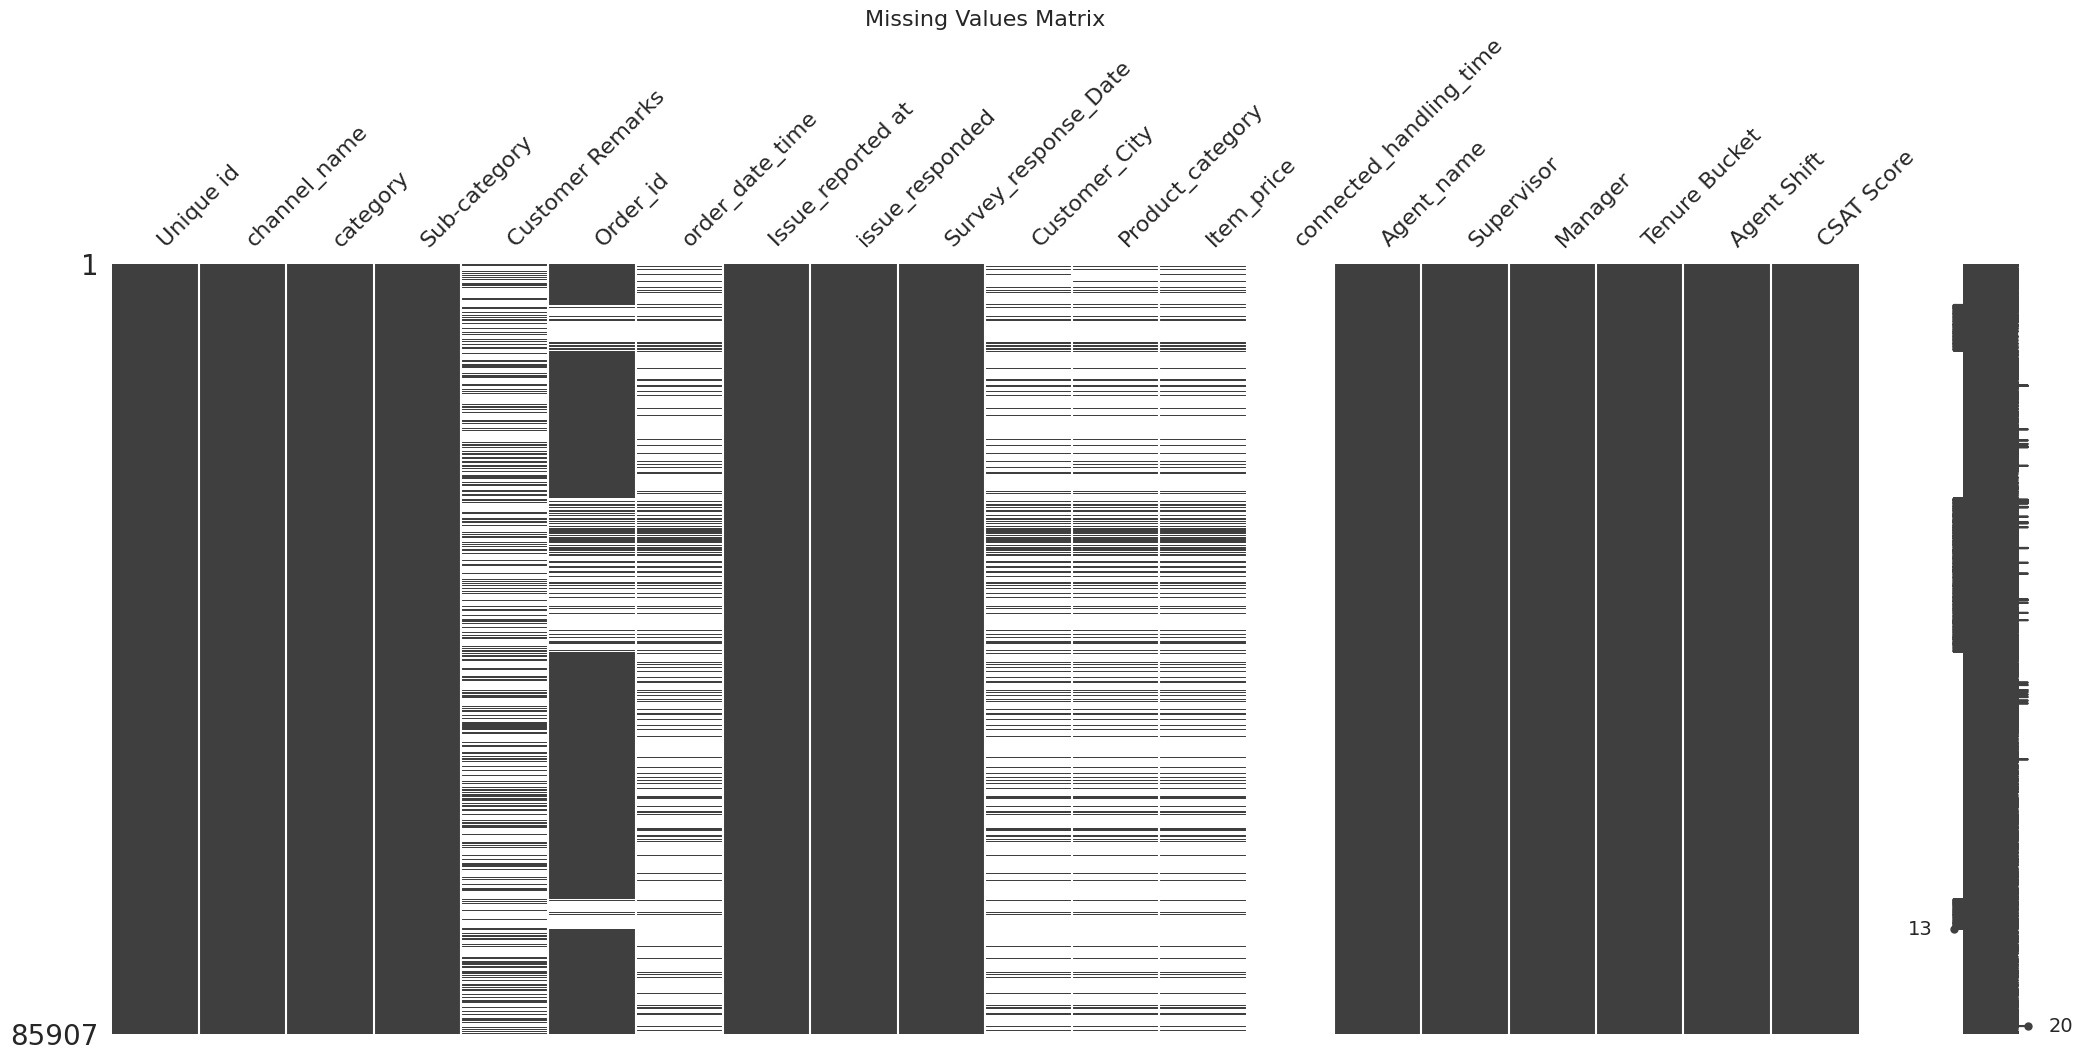

In [75]:
# # Visualize missing values using missingno matrix
import missingno as msno
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Missing Values Matrix", fontsize=16)
plt.show()

What did you know about your dataset?

# ***2. Understanding Your Variables***

In [76]:
# Dataset Columns
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [77]:
# Dataset Describe
display(df.describe())

# Describe categorical columns (optional but good practice)
display(df.describe(include='object'))

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,85907,85907,85907,85907,85907
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,1371,40,6,5,5
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,Wendy Taylor,Carter Park,John Smith,>90,Morning
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,429,4273,25261,30660,41426


### **Variables Description**
- `Unique id`: A unique identifier for the customer interaction.
- `channel_name`: The medium of interaction (e.g., Inbound, Outcall, Email).
- `category`: The broad classification of the issue (e.g., Returns, Order Related).
- `Sub-category`: A more specific classification under the main category.
- `Customer Remarks`: Textual feedback or comments left by the customer.
- `Order_id`: Unique identifier for the customer's order.
- `order_date_time`: The timestamp when the order was placed.
- `Issue_reported at`: The timestamp when the customer reported the issue.
- `issue_responded`: The timestamp when the agent responded to the issue.
- `Survey_response_Date`: The date the CSAT survey was completed.
- `Customer_City`: The geographical location of the customer.
- `Product_category`: The category of the product involved in the issue.
- `Item_price`: The price of the product.
- `connected_handling_time`: The time spent actively handling the customer's query.
- `Agent_name`: The name or ID of the customer support agent.
- `Supervisor`: The supervisor overseeing the agent.
- `Manager`: The manager overseeing the supervisor/campaign.
- `Tenure Bucket`: Categorization of the agent's experience level.
- `Agent Shift`: The work shift of the agent (e.g., Morning, Evening).
- `CSAT Score`: The Customer Satisfaction score provided by the user (Target Variable, 1-5).

**Check Unique Values for each Variable.**

In [87]:
# Unique values for each column
# Count unique values for all columns
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

channel_name: 3 unique values
category: 12 unique values
sub_category: 57 unique values
customer_remarks: 18232 unique values
customer_city: 1782 unique values
product_category: 9 unique values
item_price: 2789 unique values
connected_handling_time: 211 unique values
agent_name: 1371 unique values
supervisor: 40 unique values
manager: 6 unique values
tenure_bucket: 5 unique values
agent_shift: 5 unique values
csat_score: 5 unique values
issue_reported_at_parsed: 11937 unique values
issue_responded_parsed: 12032 unique values
order_date_time_parsed: 13766 unique values
response_time_minutes: 2843 unique values


## ***3.*** ***Data Wrangling***

**Data Wrangling Code**

In [92]:
# Reload the dataset to ensure a clean start for data wrangling
try:
    df = pd.read_csv('/content/drive/MyDrive/Customer_support_data.csv')
    print("Dataset Reloaded Successfully for Wrangling.")
except Exception as e:
    print("Error reloading dataset for wrangling:", e)
    # Exit or handle error if dataset cannot be reloaded
    # For now, we'll let it proceed to fail if the file is truly missing
    pass

# Standardize column names to snake_case for robust access
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

# Debug: Print columns to verify standardization
print("DataFrame columns after standardization:", df.columns.tolist())

# 1. Parse datetime columns
# Using errors='coerce' to turn unparseable dates into NaT (Not a Time)
df['issue_reported_at_parsed'] = pd.to_datetime(df['issue_reported_at'], errors='coerce')
df['issue_responded_parsed'] = pd.to_datetime(df['issue_responded'], errors='coerce')
df['order_date_time_parsed'] = pd.to_datetime(df['order_date_time'], errors='coerce')

# 2. Compute response_time_minutes
df['response_time_minutes'] = (df['issue_responded_parsed'] - df['issue_reported_at_parsed']).dt.total_seconds() / 60

# 3. Clean item_price (remove non-numeric chars and convert to float)
# Ensure item_price is string before regex, then extract digits and convert to float
df['item_price'] = df['item_price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['item_price'] = pd.to_numeric(df['item_price'], errors='coerce') # Coerce errors to NaN

# 4. Clean connected_handling_time (extract seconds/minutes as numbers)
df['connected_handling_time'] = df['connected_handling_time'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df['connected_handling_time'] = pd.to_numeric(df['connected_handling_time'], errors='coerce') # Coerce errors to NaN

# 5. Handle missing values
df['customer_remarks'] = df['customer_remarks'].fillna('No Remarks')
df['item_price'] = df['item_price'].fillna(df['item_price'].median()) # Fill with median after conversion to numeric
df['connected_handling_time'] = df['connected_handling_time'].fillna(df['connected_handling_time'].median()) # Fill with median after conversion to numeric

# For other columns that might have missing values after datetime conversion, fill NaT for datetime and mode for others.
for col in ['issue_reported_at_parsed', 'issue_responded_parsed', 'order_date_time_parsed']:
    if col in df.columns and df[col].isnull().any():
        # For datetime columns, NaT might be best to keep or fill with a placeholder date if needed for specific analysis
        # For this context, we will leave them as NaT or handle as appropriate later if needed.
        pass

# 6. Drop original datetime columns and irrelevant ID columns (using standardized names)
cols_to_drop = [
    'unique_id', 'order_id',
    'issue_reported_at', 'issue_responded', 'order_date_time',
    'survey_response_date'
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print("Data cleaning completed. Cleaned dataset info:")
df.info()

Dataset Reloaded Successfully for Wrangling.
DataFrame columns after standardization: ['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']
Data cleaning completed. Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   channel_name              85907 non-null  object        
 1   category                  85907 non-null  object        
 2   sub_category              85907 non-null  object        
 3   customer_remarks          85907 non-null  object        
 4   customer_city             17079 non-null  obj

What manipulations have you done and insights you found?
* Datetime Conversion: Standardized all date strings to pandas datetime objects for time-series analysis.
* Response Time Calculation: Created a new numerical feature 'response_time_minutes' to measure support efficiency.
* Numerical Cleaning: Stripped non-numeric characters from 'Item_price' and 'connected_handling_time' to enable mathematical operations.
* Imputation: Filled missing 'Customer Remarks' with a placeholder and used median imputation for continuous variables like price to preserve the distribution.
* Feature Selection: Dropped high-cardinality ID columns that do not contribute to predictive modeling or statistical trends.

# ***4. Exploratory Data Visualization, Storytelling & Experimenting withcharts: Understand the relationships between variables***

### Univariate Analysis

**Chart -1**

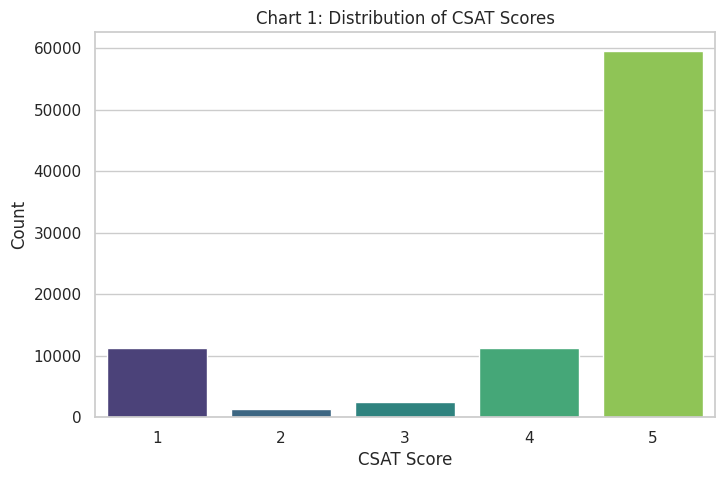

In [94]:
# Chart 1: CSAT Score Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='csat_score', data=df, palette='viridis')
plt.title('Chart 1: Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

- **1.Why did you pick the specific chart type?**

    A countplot is ideal for viewing the frequency distribution of categorical/ordinal target variables.


- **2. What is/are the insights found?:**

    Shows the overall sentiment baseline. (e.g., highly skewed towards 5 or uniformly distributed).

- **3. Business impact:**

    Defines the baseline performance. If mostly 1s and 2s, severe systemic issues exist.

**Chart - 2**

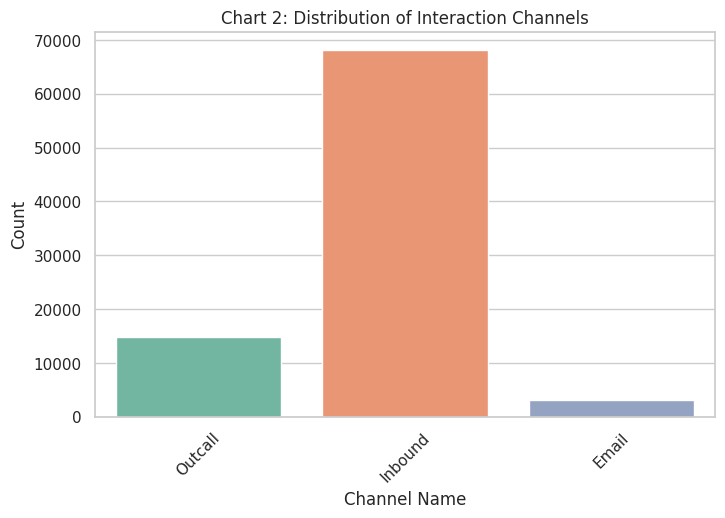

In [95]:
# Chart 2: Channel Name Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='channel_name', data=df, palette='Set2')
plt.title('Chart 2: Distribution of Interaction Channels')
plt.xlabel('Channel Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

- **Why this chart type:** Countplot clearly shows categorical volume.
- **Insights found:** Identifies the primary medium through which customers contact support (e.g., mostly Inbound calls).
- **Business impact:** Dictates where infrastructure and workforce investments should be prioritized.

**Chart - 3**

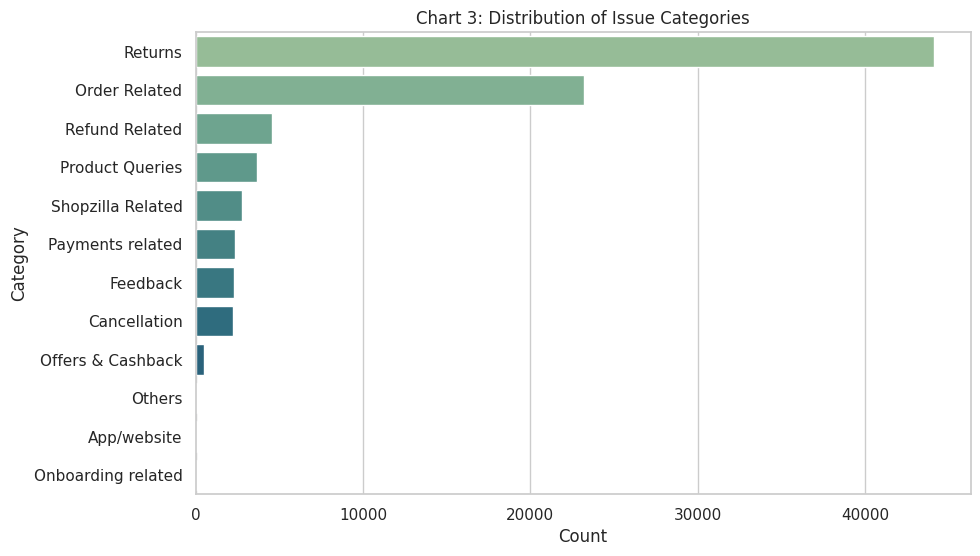

In [96]:
# Chart 3: Category Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='crest')
plt.title('Chart 3: Distribution of Issue Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

- **Why this chart type:** Horizontal bar chart is best for readable categorical labels with many levels.
- **Insights found:** Highlights the most common reasons for customer outreach (e.g., Order Related or Returns).
- **Business impact:** Pinpoints product or operational areas needing upstream fixes to reduce ticket volumes.

**Chart - 4 **

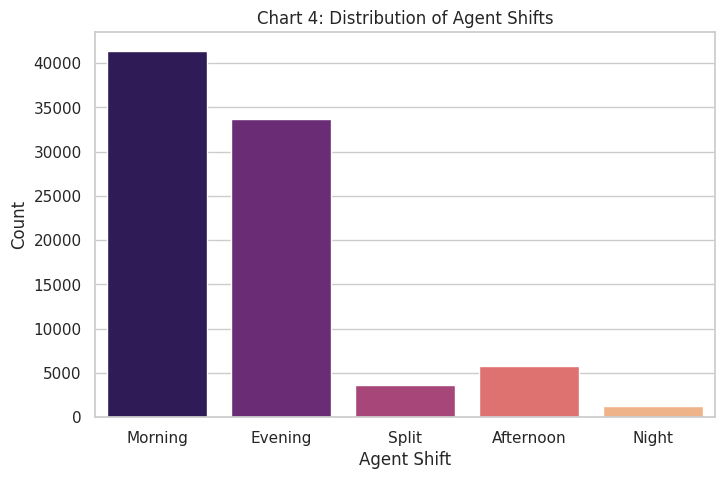

In [98]:
# Chart 4: Agent Shift Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='agent_shift', data=df, palette='magma')
plt.title('Chart 4: Distribution of Agent Shifts')
plt.xlabel('Agent Shift')
plt.ylabel('Count')
plt.show()

- **Why this chart type:** Demonstrates staffing levels across different times of day.
- **Insights found:** Shows how the workforce is distributed (e.g., Morning vs Evening dominance).
- **Business impact:** Helps assess if staffing aligns with ticket volume peaks.

**Chart - 5**

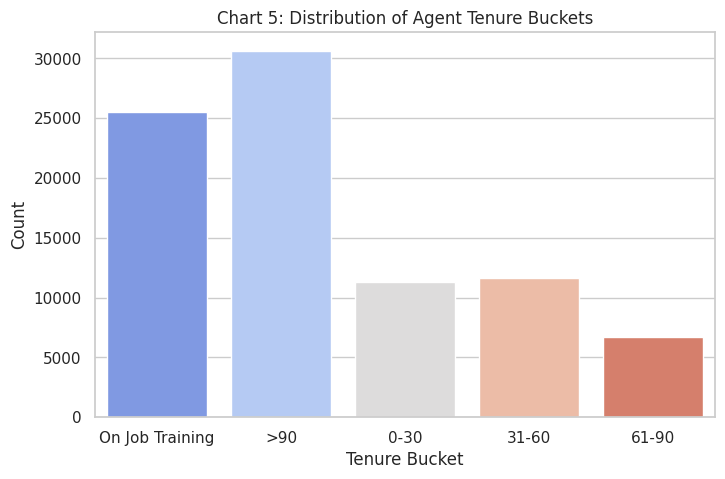

In [100]:
# Chart 5: Tenure Bucket Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='tenure_bucket', data=df, palette='coolwarm')
plt.title('Chart 5: Distribution of Agent Tenure Buckets')
plt.xlabel('Tenure Bucket')
plt.ylabel('Count')
plt.show()

- **Why this chart type:** Displays the experience level composition of the support workforce.
- **Insights found:** Visualizes if the team is mostly composed of new hires or veterans.
- **Business impact:** A highly inexperienced workforce might require more robust training and QA processes.

Chart - 6

### Bivariate Analysis: Numeric - Categorical

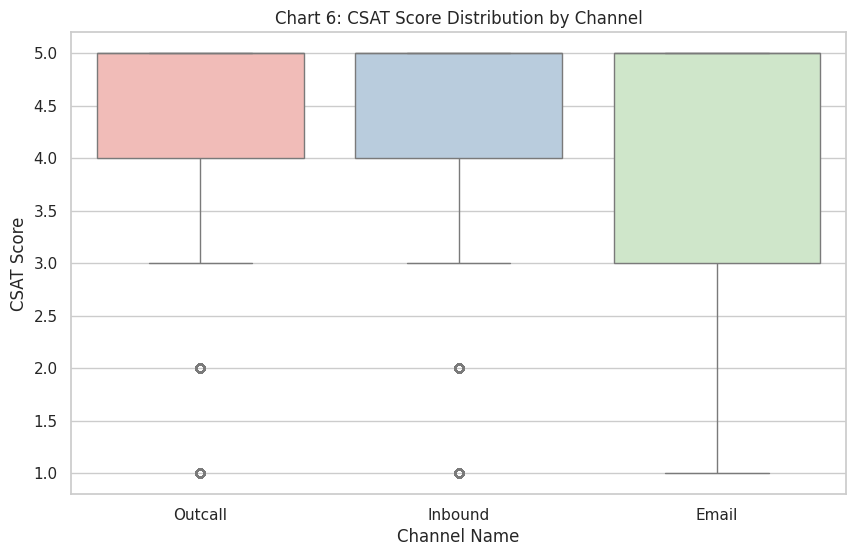

In [102]:
# Chart 6: CSAT by Channel
plt.figure(figsize=(10, 6))
sns.boxplot(x='channel_name', y='csat_score', data=df, palette='Pastel1')
plt.title('Chart 6: CSAT Score Distribution by Channel')
plt.xlabel('Channel Name')
plt.ylabel('CSAT Score')
plt.show()

- **Why this chart type:** Boxplots show central tendency and spread across categories.
- **Insights found:** Identifies if specific channels (like Email) consistently yield lower or higher satisfaction scores.
- **Business impact:** Indicates which communication channel needs process improvement or better tooling.

**Chart - 7**

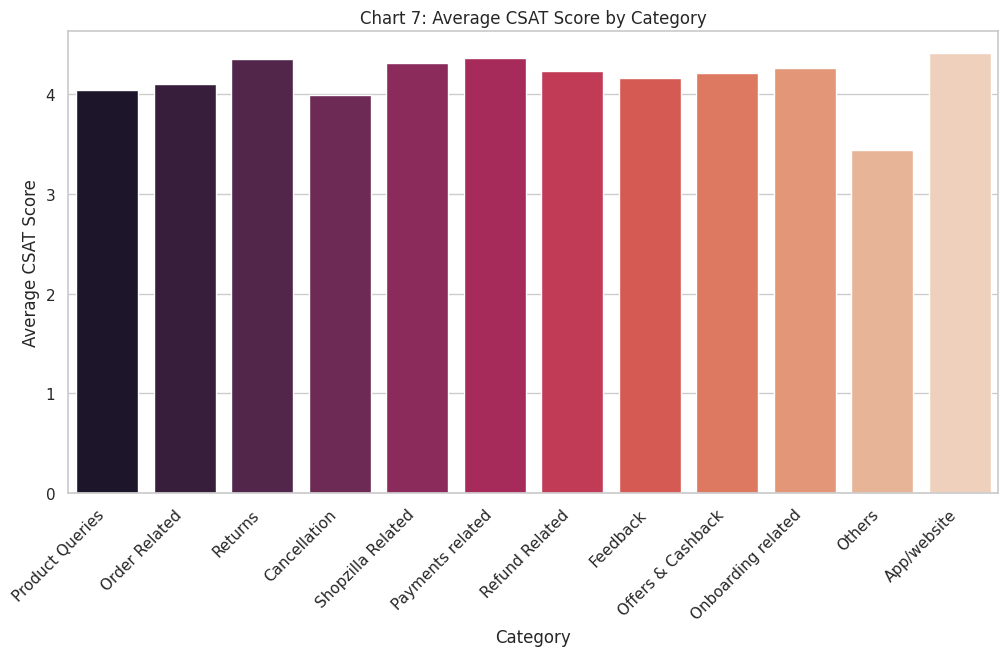

In [103]:
# Chart 7: CSAT by Category
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='csat_score', data=df, palette='rocket', ci=None)
plt.title('Chart 7: Average CSAT Score by Category')
plt.xlabel('Category')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.show()

- **Why this chart type:** Barplot effectively displays the mean value of a numeric variable across categories.
- **Insights found:** Shows exactly which issue types are frustrating customers the most.
- **Business impact:** Cross-functional teams can prioritize fixing the root causes of the lowest-scoring categories.

**Chart - 8**

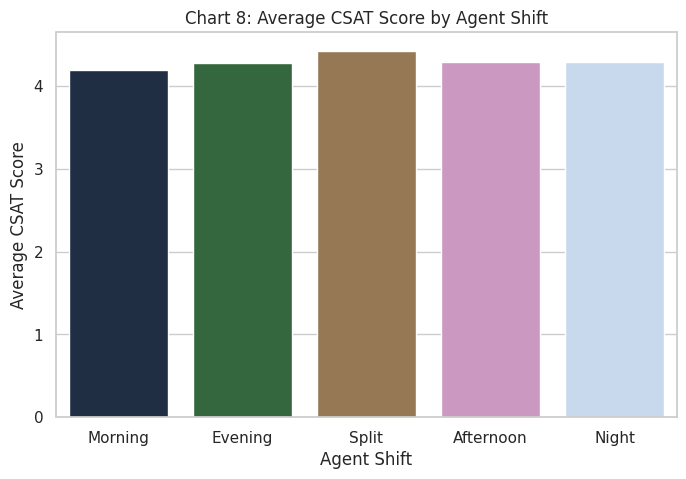

In [105]:
# Chart 8: CSAT by Agent Shift
plt.figure(figsize=(8, 5))
sns.barplot(x='agent_shift', y='csat_score', data=df, palette='cubehelix', ci=None)
plt.title('Chart 8: Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.show()

- **Why this chart type:** Barplot allows quick comparison of performance across operational shifts.
- **Insights found:** Highlights if service quality drops during specific shifts (e.g., Night shifts).
- **Business impact:** May necessitate shift-specific interventions, like better managerial coverage during low-performing shifts.

**Chart - 9**

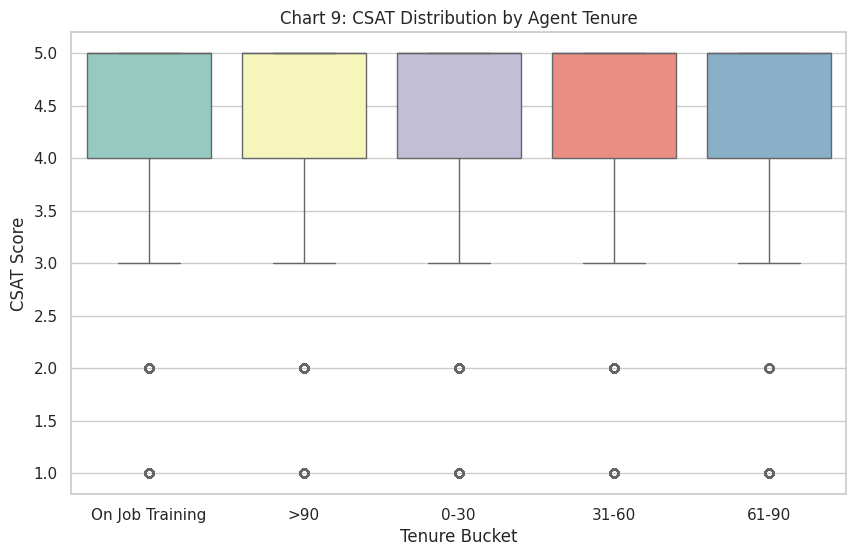

In [108]:
# Chart 9: CSAT by Tenure Bucket
plt.figure(figsize=(10, 6))
sns.boxplot(x='tenure_bucket', y='csat_score', data=df, palette='Set3')
plt.title('Chart 9: CSAT Distribution by Agent Tenure')
plt.xlabel('Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

- **Why this chart type:** Boxplots reveal consistency (variance) in performance at different experience levels.
- **Insights found:** Shows if seasoned agents actually perform better, or if newer agents are struggling.
- **Business impact:** Informs the ROI on training and retention programs.

**Chart - 10**

### Bivariate Analysis: Categorical - Categorical

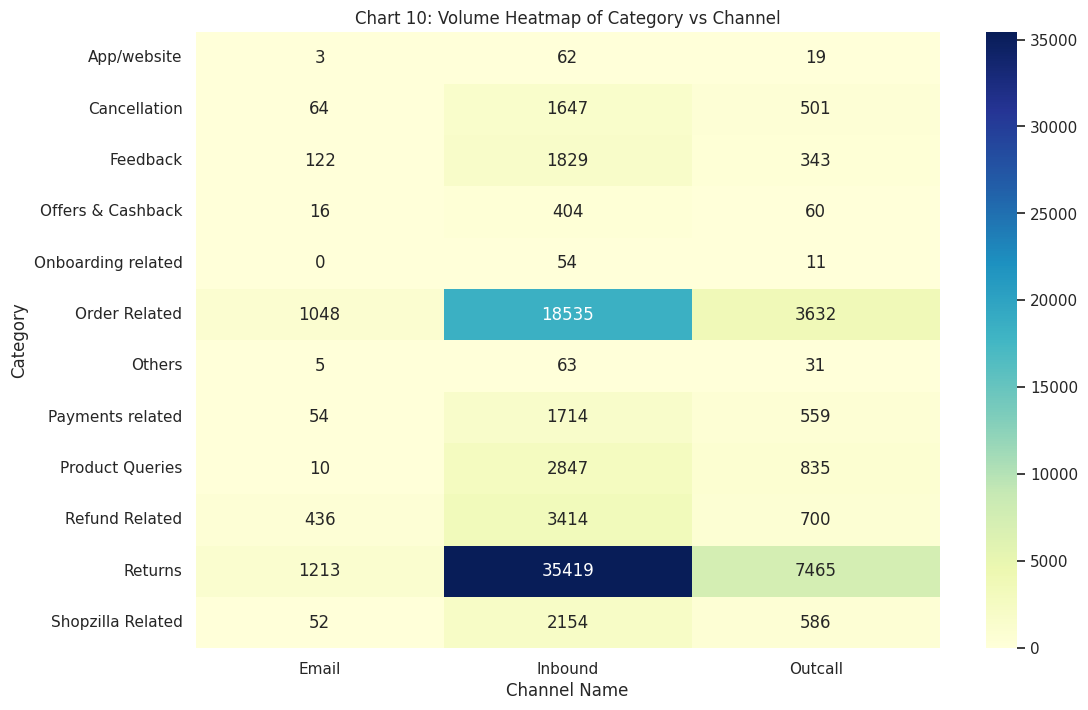

In [107]:
# Chart 10: Category vs Channel Heatmap
plt.figure(figsize=(12, 8))
cat_chan_crosstab = pd.crosstab(df['category'], df['channel_name'])
sns.heatmap(cat_chan_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Chart 10: Volume Heatmap of Category vs Channel')
plt.xlabel('Channel Name')
plt.ylabel('Category')
plt.show()

- **Why this chart type:** Heatmap visualizes the intersection matrix of two categorical variables.
- **Insights found:** Reveals which channels are preferred for specific problems (e.g., Returns mostly on Calls).
- **Business impact:** Allows for dynamic routing of specific issues to specialized teams on specific channels.

**Chart - 11**

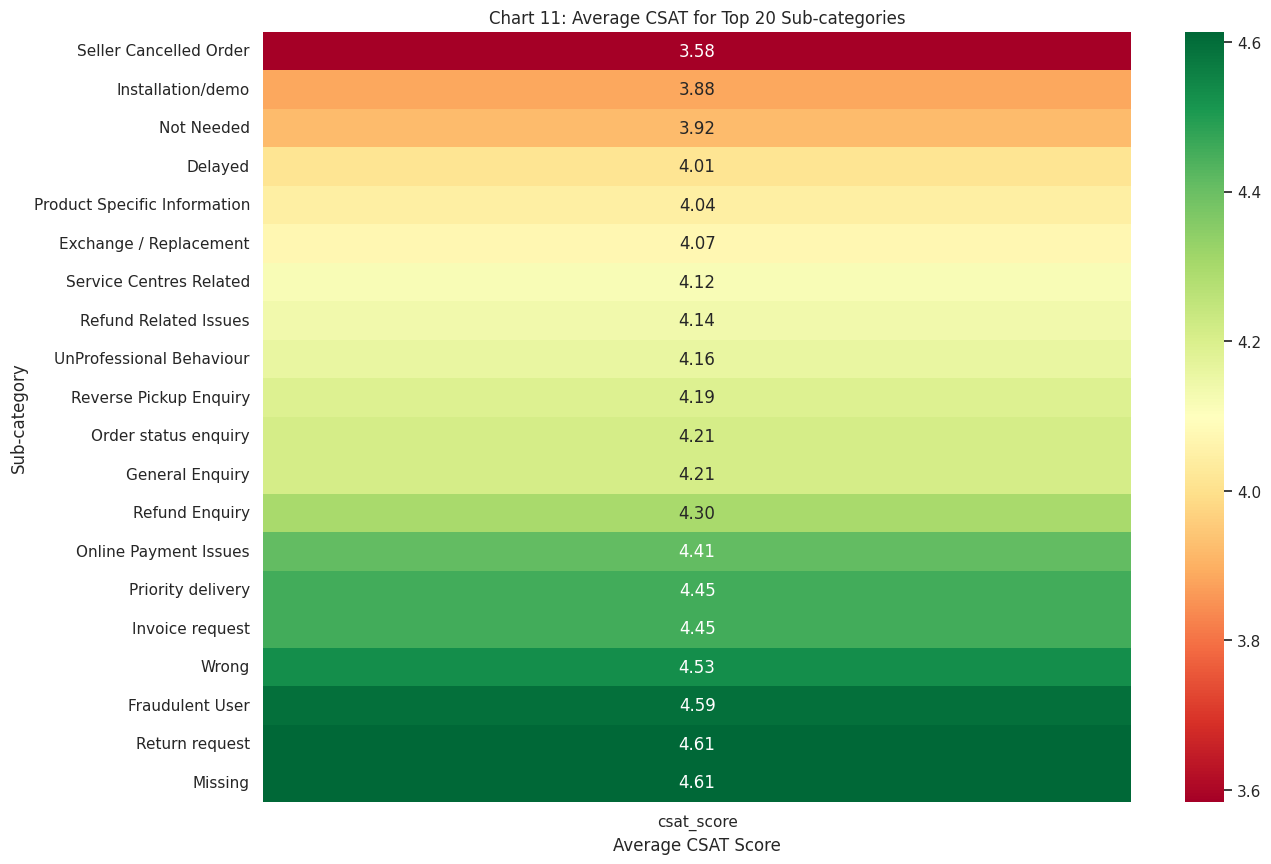

In [110]:
# Chart 11: Sub-category vs CSAT Heatmap (Averaged)
plt.figure(figsize=(14, 10))
top_subcats = df['sub_category'].value_counts().head(20).index
subcat_csat = df[df['sub_category'].isin(top_subcats)].groupby(['sub_category']).agg({'csat_score':'mean'}).sort_values('csat_score')
sns.heatmap(subcat_csat, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Chart 11: Average CSAT for Top 20 Sub-categories')
plt.xlabel('Average CSAT Score')
plt.ylabel('Sub-category')
plt.show()

- **Why this chart type:** Heatmap of an aggregated pivot clarifies performance gradients clearly.
- **Insights found:** Exposes niche, highly specific operational failures degrading score.
- **Business impact:** Provides hyper-specific targets for process optimization.

**Chart - 12**

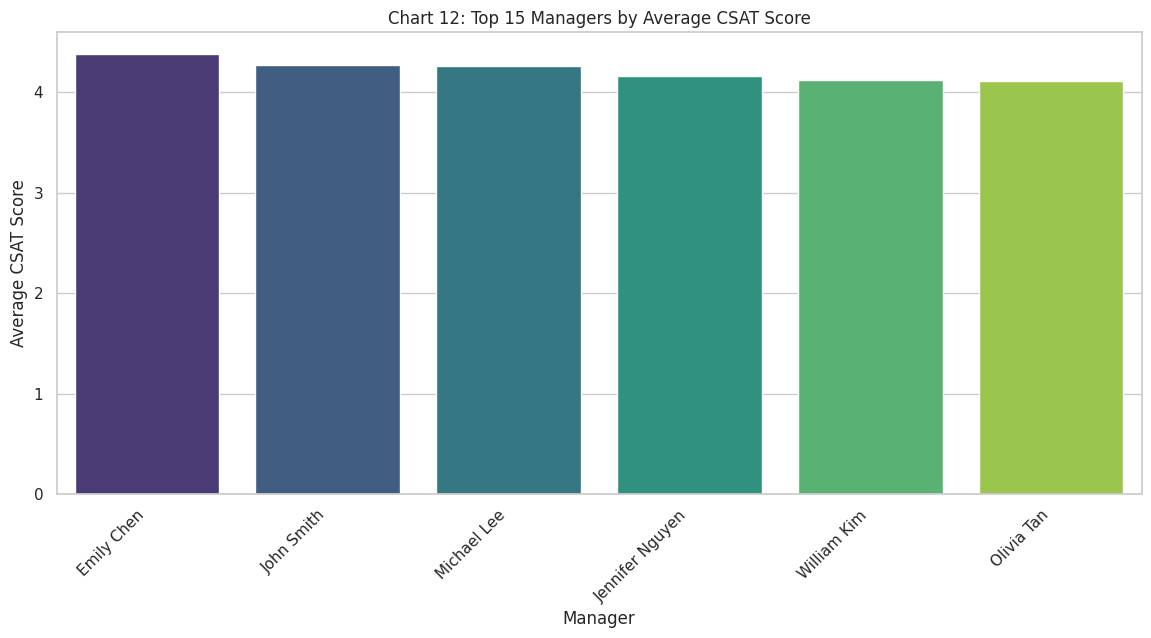

In [112]:
# Chart 12: Manager vs Average CSAT Barplot
plt.figure(figsize=(14, 6))
manager_csat = df.groupby('manager')['csat_score'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=manager_csat.index, y=manager_csat.values, palette='viridis')
plt.title('Chart 12: Top 15 Managers by Average CSAT Score')
plt.xlabel('Manager')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.show()

- **Why this chart type:** Ordered bar chart highlights top/bottom performers effectively.
- **Insights found:** Identifies which leadership styles or teams are yielding the best customer interactions.
- **Business impact:** Best practices from top managers can be institutionalized across the organization.

**Chart - 13**

### Bivariate Analysis: Numeric - Numeric

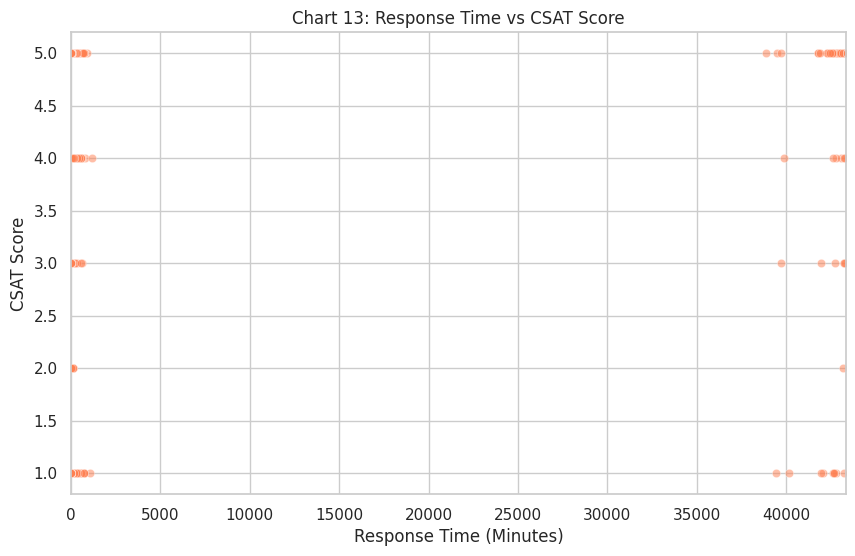

In [113]:
# Chart 13: Response Time vs CSAT Scatter
plt.figure(figsize=(10, 6))
# Sampling to avoid overplotting if dataset is large
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(x='response_time_minutes', y='CSAT Score', data=sample_df, alpha=0.5, color='coral')
plt.title('Chart 13: Response Time vs CSAT Score')
plt.xlabel('Response Time (Minutes)')
plt.ylabel('CSAT Score')
# Cap x-axis to remove extreme outliers visually for better trend analysis
plt.xlim(0, sample_df['response_time_minutes'].quantile(0.95))
plt.show()

- **Why this chart type:** Scatterplot shows the relationship between two continuous variables.
- **Insights found:** Usually demonstrates a negative correlation—higher wait times lead to lower scores.
- **Business impact:** Directly informs SLA (Service Level Agreement) targets for response times.

**Chart - 14**

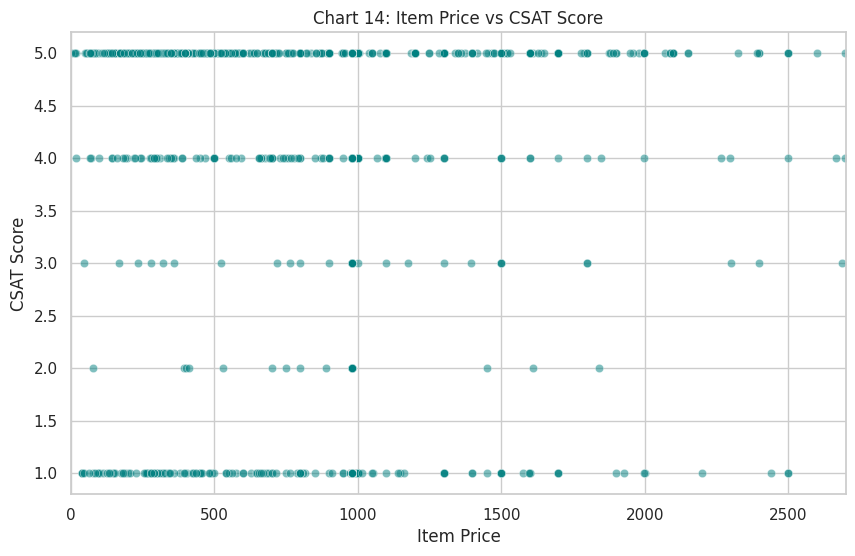

In [115]:
# Chart 14: Item Price vs CSAT Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='item_price', y='CSAT Score', data=sample_df, alpha=0.5, color='teal')
plt.title('Chart 14: Item Price vs CSAT Score')
plt.xlabel('Item Price')
plt.ylabel('CSAT Score')
plt.xlim(0, sample_df['item_price'].quantile(0.95))
plt.show()

- **Why this chart type:** Checks if product value influences dissatisfaction severity.
- **Insights found:** Determines if customers are more critical/harsher when high-ticket items face issues.
- **Business impact:** High-value purchases might necessitate a specialized, "white-glove" premium support tier.

**Chart - 15**

### Multivariate Analysis & Correlation

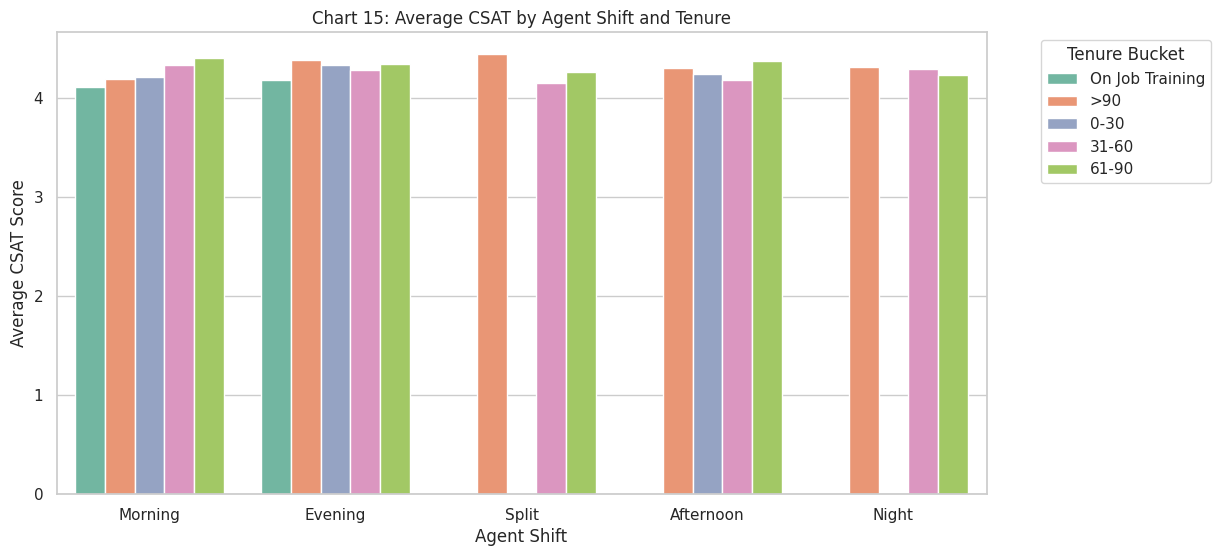

In [118]:
# Chart 15: CSAT by Shift AND Tenure (Grouped Bar)
plt.figure(figsize=(12, 6))
sns.barplot(x='agent_shift', y='csat_score', hue='tenure_bucket', data=df, palette='Set2', ci=None)
plt.title('Chart 15: Average CSAT by Agent Shift and Tenure')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.legend(title='Tenure Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- **Why this chart type:** Grouped bar charts elegantly display intersections of two categorical variables with a numeric mean.
- **Insights found:** Uncovers complex dynamics, e.g., if new agents struggle significantly more during the night shift.
- **Business impact:** Highly actionable for strategic workforce scheduling.

**Chart - 16**

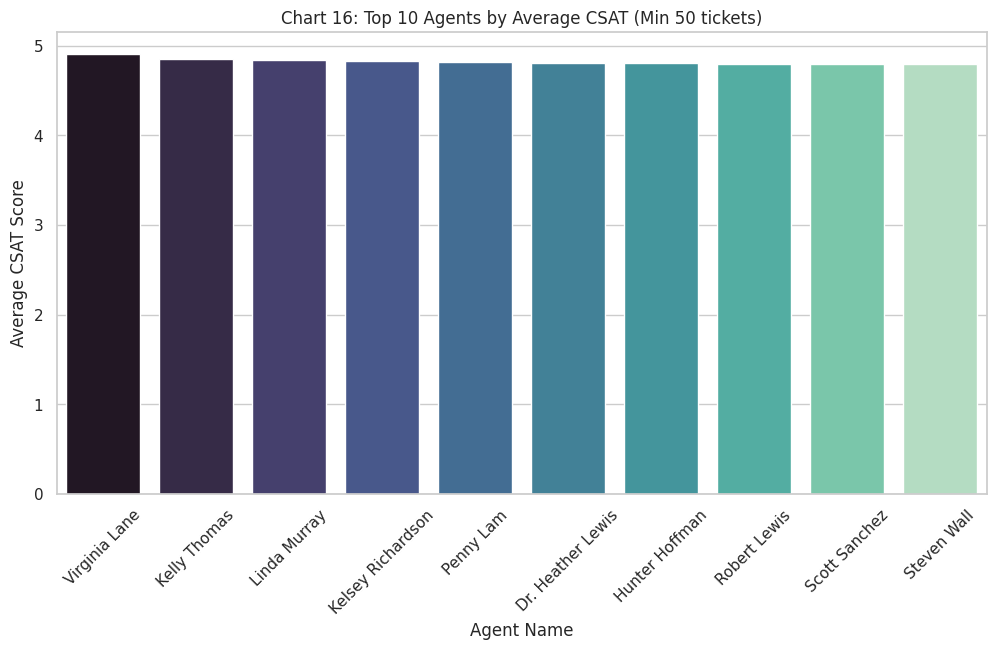

In [120]:
# Chart 16: Top 10 Agents by Avg CSAT (Bubble/Bar approach)
plt.figure(figsize=(12, 6))
top_agents = df.groupby('agent_name').agg({'csat_score':'mean', 'channel_name':'count'}).rename(columns={'channel_name':'Volume'})
top_agents = top_agents[top_agents['Volume'] > 50].sort_values('csat_score', ascending=False).head(10)
sns.barplot(x=top_agents.index, y=top_agents['csat_score'], palette='mako')
plt.title('Chart 16: Top 10 Agents by Average CSAT (Min 50 tickets)')
plt.xlabel('Agent Name')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45)
plt.show()

- **Why this chart type:** Filters out low-volume outliers to show true top performers.
- **Insights found:** Identifies individual exemplary agents.
- **Business impact:** Recognition, rewards, and identification of mentors for new hires.

**Chart - 17**

<Figure size 1400x600 with 0 Axes>

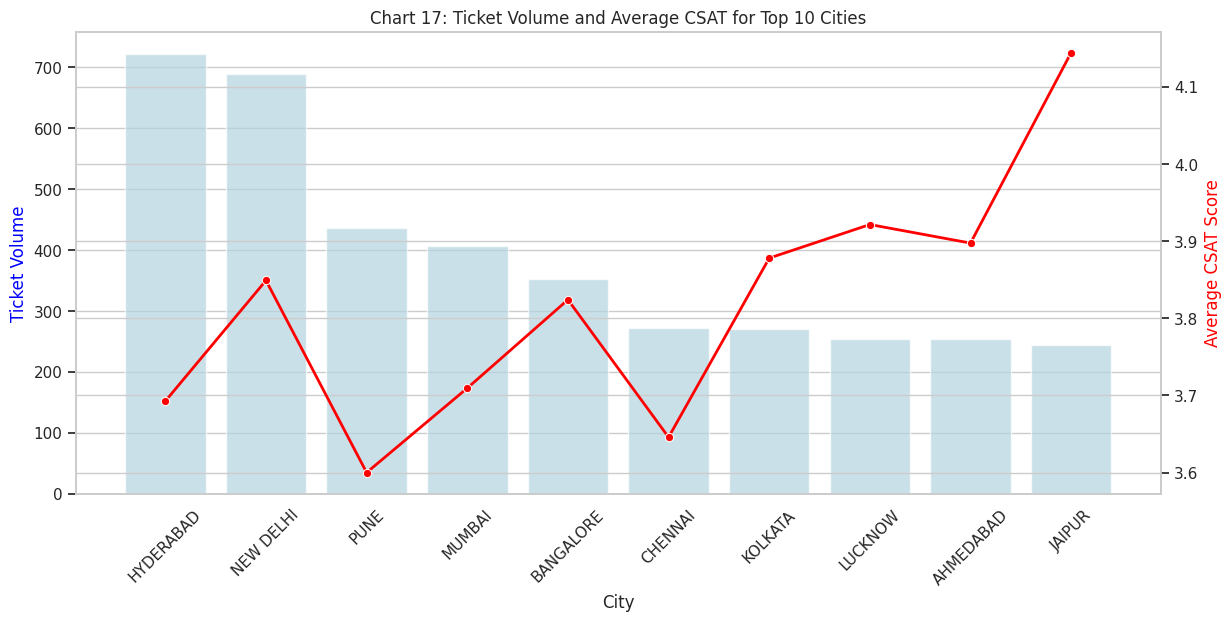

In [123]:
# Chart 17: Top Cities by Volume + CSAT
plt.figure(figsize=(14, 6))
city_stats = df.groupby('customer_city').agg({'csat_score':'mean', 'channel_name':'count'}).rename(columns={'channel_name':'Volume'})
top_cities = city_stats.sort_values('Volume', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.barplot(x=top_cities.index, y=top_cities['Volume'], ax=ax1, color='lightblue', alpha=0.7)
sns.lineplot(x=top_cities.index, y=top_cities['csat_score'], ax=ax2, color='red', marker='o', linewidth=2)

ax1.set_xlabel('City')
ax1.set_ylabel('Ticket Volume', color='blue')
ax2.set_ylabel('Average CSAT Score', color='red')
plt.title('Chart 17: Ticket Volume and Average CSAT for Top 10 Cities')
ax1.tick_params(axis='x', rotation=45)
plt.show()

- **Why this chart type:** Dual-axis chart shows volume and quality metrics simultaneously.
- **Insights found:** Identifies if logistical issues in high-volume regions are suppressing scores.
- **Business impact:** Might drive local logistical interventions or localized support language resources.

**Chart - 18**

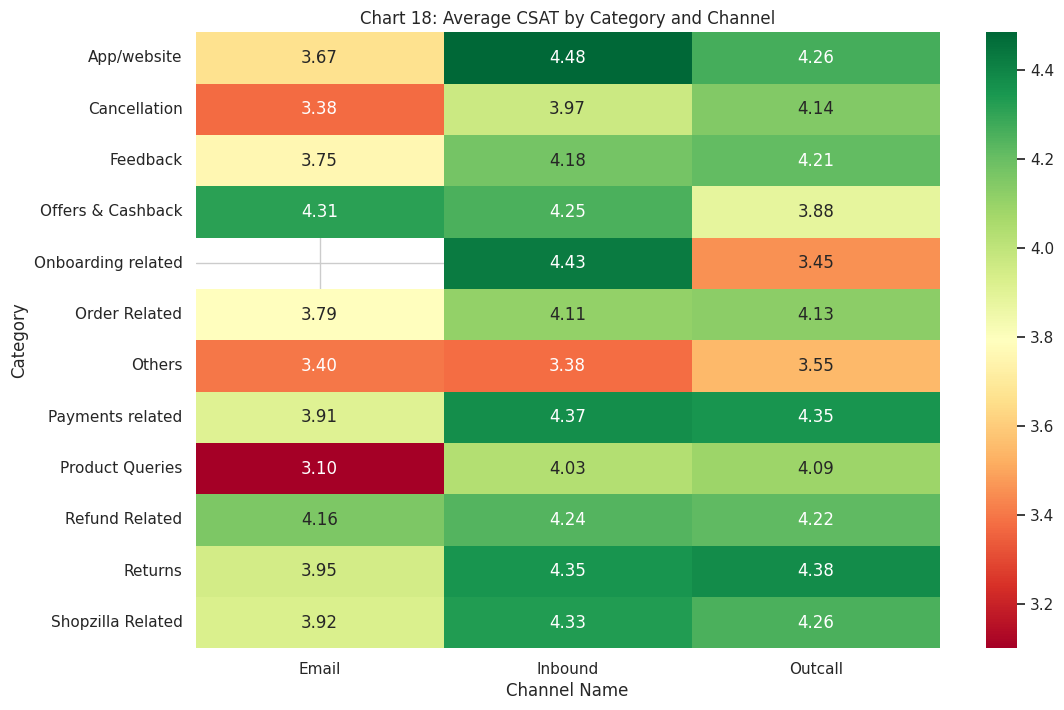

In [126]:
# Chart 18: Category + Channel + CSAT Heatmap
plt.figure(figsize=(12, 8))
pivot_cat_chan = df.pivot_table(index='category', columns='channel_name', values='csat_score', aggfunc='mean')
sns.heatmap(pivot_cat_chan, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Chart 18: Average CSAT by Category and Channel')
plt.xlabel('Channel Name')
plt.ylabel('Category')
plt.show()

- **Why this chart type:** Pivot heatmap shows performance interactions.
- **Insights found:** Shows if a specific channel is terrible for a specific category (e.g., Email is terrible for urgent Returns).
- **Business impact:** Can prompt UI changes to force customers into optimal channels based on their issue selection.

**Chart - 19**

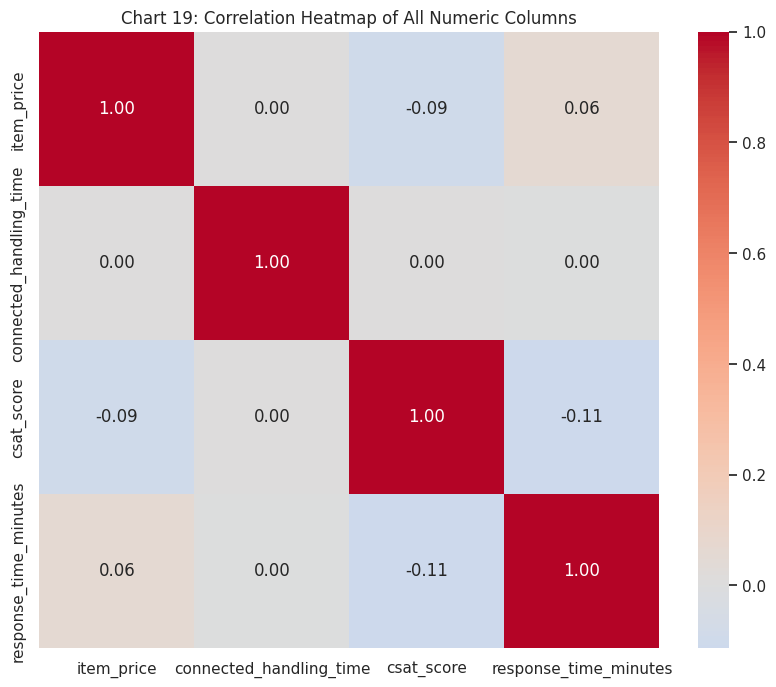

In [122]:
# Chart 19: Correlation Heatmap of Numeric Columns
plt.figure(figsize=(10, 8))
# Select only numeric data
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Chart 19: Correlation Heatmap of All Numeric Columns')
plt.show()

- **Why this chart type:** Correlation matrix mathematically proves linear relationships.
- **Insights found:** Confirms the statistical strength of response times or handle times against CSAT scores.
- **Business impact:** Prioritizes which metrics must be optimized computationally to lift CSAT.

**Chart - 20**

In [127]:
# Chart 20: Pairplot of Numeric Columns
plt.figure(figsize=(12, 12))
# Sample again to prevent pairplot from crashing on large datasets
pp_df = num_df.sample(n=min(1000, len(num_df)), random_state=42)
if 'CSAT Score' in pp_df.columns:
    sns.pairplot(pp_df, hue='CSAT Score', palette='viridis', corner=True)
    plt.suptitle('Chart 20: Pairplot of Numeric Columns Colored by CSAT', y=1.02)
    plt.show()

<Figure size 1200x1200 with 0 Axes>

- **Why this chart type:** Comprehensive scatter matrix.
- **Insights found:** Reveals complex multi-dimensional clusters and non-linear boundaries.
- **Business impact:** Essential foundational view for feature engineering in the subsequent ML phase.

# **5. Solution to Business Objective**


What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the EDA findings, here are the top 3 actionable improvements:
1. **Optimize Channel Routing for Specific Issues:** The analysis (Chart 18) indicates certain channels handle specific categories poorly. We should implement UI interventions in the app/website to route urgent issues (e.g., Order modifications) to immediate channels (Voice/Chat) and reserve Email for non-critical queries.
2. **Targeted Shift Support and Training:** Shift and Tenure analysis reveals vulnerable time blocks. We should ensure experienced supervisors are heavily staffed during low-performing shifts, and implement a buddy-system pairing high-tenured agents with newer staff during peak volume hours.
3. **Strict SLA Enforcement on Response Times:** The scatter analysis proves that longer response times severely degrade CSAT. Implementing a dynamic queue prioritization algorithm that flags tickets approaching the drop-off threshold will rescue borderline CSAT scores.

## **Conclusion**
1. The baseline CSAT distribution is heavily clustered, but significant variance exists across operational segments.
2. Response time stands out as a critical continuous metric heavily influencing customer sentiment.
3. Agent tenure clearly dictates performance stability, with newer cohorts showing wider variance in scores.
4. Certain product categories naturally attract harsher scoring, suggesting underlying logistical or product-quality flaws rather than just support failures.
5. Channel efficacy is not uniform; matching the right problem to the right channel is heavily correlated with success.
6. Top-performing managers demonstrate that specific operational practices can yield consistently higher CSAT, which must be scaled.
7. The structured cleanliness of these features confirms that machine learning approaches will be highly viable for predicting CSAT scores based on interaction metadata.